<a href="https://colab.research.google.com/github/asheldrick-research/ecsm-framework/blob/main/ECSM_N46R_EXECUTED_Exact_Electromagnetic_Response_Survival_Scan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# ECSM N46R — Exact Electromagnetic Response Survival Scan

## Purpose

N45R translated real propagation observations into low-frequency ECSM constraints.
N46R performs the promised final major electromagnetic scan using the **exact** N44R response:

\[
H_j(E)=
\frac{1}{
1-(E/E_{\Omega,j})^2-iE/E_{\tau,j}
},
\]

\[
Z_E(E)=1-a_E[1-H_E(E)],
\]

\[
Z_B(E)=1+a_B[1-H_B(E)],
\]

\[
n(E)=\sqrt{\frac{Z_E(E)}{Z_B(E)}}.
\]

Here

\[
E_{\tau,j}=\frac{\hbar}{\tau_j},
\qquad
E_{\Omega,j}=\hbar\Omega_j.
\]

The scan tests:

1. exact LHAASO \(0.2\)--\(7\) TeV differential group-speed consistency;
2. exact passive transparency at \(0.2\), \(1\), and \(7\) TeV;
3. GW170817/GRB 170817A gravity--photon speed consistency at a representative \(100\) keV;
4. positive and finite constitutive response;
5. whether viable solutions require tiny tracked fractions, ultraweak damping, high inertial
   turnover, or some combination.

## Claim boundary

This is a broad deterministic Monte Carlo survival scan, not a posterior inference.
The LHAASO and transparency conditions are conservative envelopes inherited from N45R.
The model is isotropic, so the rotating-resonator anisotropy bound is recorded but not applied as
an isotropic refractive-index constraint.


In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import zipfile
import io
import json
from pathlib import Path
from scipy.constants import hbar, electron_volt, c

base = Path('/mnt/data')
outdir = base/'ecsm_n46r_outputs'
outdir.mkdir(parents=True, exist_ok=True)
pd.set_option('display.max_colwidth', 180)

print('N46R environment loaded.')


N46R environment loaded.



## 1. Import the N45R observational ledger


In [ ]:

n45_zip = base/'ecsm_n45r_outputs.zip'
assert n45_zip.exists()

with zipfile.ZipFile(n45_zip) as zf:
    ledger45 = json.loads(zf.read('n45r_claim_ledger.json'))
    opacity45 = pd.read_csv(io.BytesIO(zf.read('n45r_TeV_transparency_translation.csv')))
    resonator45 = pd.read_csv(io.BytesIO(zf.read('n45r_resonator_anisotropy_constraint.csv')))

EQG2_GeV = float(ledger45['LHAASO']['EQG2_GeV_lower'])
gw_speed_bound = float(ledger45['GW170817']['conservative_abs_relative_speed_bound'])
path_Mpc = float(ledger45['TeV_transparency']['ECSM_operational_path_Mpc'])

parsec_m = 3.085677581491367e16
path_m = path_Mpc*1e6*parsec_m

print({
    'EQG2_GeV':EQG2_GeV,
    'GW_speed_bound':gw_speed_bound,
    'path_Mpc':path_Mpc
})


{'EQG2_GeV': 732533999999.9999, 'GW_speed_bound': 3e-15, 'path_Mpc': 649.433476436916}



## 2. Exact response and group velocity

For energy \(E=\hbar\omega\), define

\[
n_g(E)
=
\operatorname{Re}
\left[
n(E)+E\frac{dn}{dE}
\right],
\]

\[
\frac{v_g}{c}=\frac1{n_g}.
\]

The derivative is evaluated symmetrically in logarithmic energy.


In [ ]:

def exact_response(E_GeV, aE, aB, EtauE, EtauB, EomegaE, EomegaB):
    # Stable formulation that preserves shifts far below machine epsilon relative to unity.
    qE = (E_GeV/EomegaE)**2 + 1j*(E_GeV/EtauE)
    qB = (E_GeV/EomegaB)**2 + 1j*(E_GeV/EtauB)

    deltaE = aE*qE/(1.0-qE)
    deltaB = -aB*qB/(1.0-qB)

    ZE = 1.0 + deltaE
    ZB = 1.0 + deltaB

    ratio_minus_one = (deltaE-deltaB)/(1.0+deltaB)
    sqrt_ratio = np.sqrt(1.0+ratio_minus_one)
    n_minus_one = ratio_minus_one/(sqrt_ratio+1.0)

    DqE = 2.0*(E_GeV/EomegaE)**2 + 1j*(E_GeV/EtauE)
    DqB = 2.0*(E_GeV/EomegaB)**2 + 1j*(E_GeV/EtauB)

    DdeltaE = aE*DqE/(1.0-qE)**2
    DdeltaB = -aB*DqB/(1.0-qB)**2

    Dln_ratio = DdeltaE/(1.0+deltaE) - DdeltaB/(1.0+deltaB)
    ng_minus_one = n_minus_one + 0.5*(1.0+n_minus_one)*Dln_ratio
    vg_minus_one = -ng_minus_one/(1.0+ng_minus_one)

    return ZE, ZB, n_minus_one, np.real(vg_minus_one)

def group_velocity_deviation(E_GeV, aE, aB, EtauE, EtauB, EomegaE, EomegaB):
    _,_,n_minus_one,vg_minus_one = exact_response(
        E_GeV,aE,aB,EtauE,EtauB,EomegaE,EomegaB
    )
    return vg_minus_one, n_minus_one

# Maxwell limit.
test = group_velocity_deviation(
    1e3,
    np.array([0.0]),np.array([0.0]),
    np.array([1e10]),np.array([1e10]),
    np.array([1e10]),np.array([1e10])
)
assert np.isclose(test[0][0],0.0)
assert np.isclose(test[1][0],0.0)
print('PASS: stable exact evaluator recovers Maxwell propagation.')


PASS: stable exact evaluator recovers Maxwell propagation.



## 3. Exact observational envelopes

### LHAASO differential group speed

Using the published quadratic lower scale, the conservative differential envelope between
\(E_{\rm lo}=0.2\) TeV and \(E_{\rm hi}=7\) TeV is

\[
\boxed{
\Delta_{v,{\rm max}}
=
\frac32
\frac{E_{\rm hi}^2-E_{\rm lo}^2}{E_{\rm QG,2}^2}.
}
\]

The exact model must satisfy

\[
\left|
\frac{v_g(E_{\rm hi})-v_g(E_{\rm lo})}{c}
\right|
<
\Delta_{v,{\rm max}}.
\]

### Transparency

The extra amplitude optical depth is

\[
\mathcal T(E)
=
\frac{E}{\hbar c}
\operatorname{Im}n(E)\,L.
\]

The conservative survival condition is

\[
\mathcal T(E)<1
\]

at \(0.2\), \(1\), and \(7\) TeV.

### Multimessenger speed

At a representative \(100\) keV,

\[
\left|
\frac{v_g}{c}-1
\right|
<
3\times10^{-15}.
\]


In [ ]:

E_lo_GeV = 0.2e3
E_mid_GeV = 1.0e3
E_hi_GeV = 7.0e3
E_gw_GeV = 100e-6

lhaaso_delta_v_max = 1.5*(E_hi_GeV**2-E_lo_GeV**2)/EQG2_GeV**2

assert lhaaso_delta_v_max > 0
print({'LHAASO_pairwise_delta_v_max':lhaaso_delta_v_max})


{'LHAASO_pairwise_delta_v_max': 1.3686017605129108e-16}



## 4. Broad six-parameter scan

The scan covers:

\[
10^{-40}\le a_E,a_B\le0.9,
\]

\[
10^3\ {\rm GeV}
\le
E_{\Omega,E},E_{\Omega,B}
\le
E_{\rm Pl},
\]

and

\[
10^3\ {\rm GeV}
\le
E_{\tau,E},E_{\tau,B}
\le
10^{50}\ {\rm GeV}.
\]

The damping-energy range extends beyond the Planck energy because \(E_\tau=\hbar/\tau\) is an
inverse damping time, not necessarily a particle mass. Very large \(E_\tau\) means extremely weak
bath coupling.


In [ ]:

rng = np.random.default_rng(46001)
N = 100_000

Epl_GeV = 1.220890e19

def log_uniform(low_exp, high_exp, size):
    return 10**rng.uniform(low_exp,high_exp,size)

aE = log_uniform(-40,np.log10(0.9),N)
aB = log_uniform(-40,np.log10(0.9),N)
EtauE = log_uniform(3,50,N)
EtauB = log_uniform(3,50,N)
EomegaE = log_uniform(3,np.log10(Epl_GeV),N)
EomegaB = log_uniform(3,np.log10(Epl_GeV),N)

assert np.all((aE>0)&(aE<=0.9))
assert np.all((aB>0)&(aB<=0.9))
print('Generated deterministic broad scan.')


Generated deterministic broad scan.


In [ ]:

vg_lo,n_lo = group_velocity_deviation(E_lo_GeV,aE,aB,EtauE,EtauB,EomegaE,EomegaB)
vg_mid,n_mid = group_velocity_deviation(E_mid_GeV,aE,aB,EtauE,EtauB,EomegaE,EomegaB)
vg_hi,n_hi = group_velocity_deviation(E_hi_GeV,aE,aB,EtauE,EtauB,EomegaE,EomegaB)
vg_gw,n_gw = group_velocity_deviation(E_gw_GeV,aE,aB,EtauE,EtauB,EomegaE,EomegaB)

ZE_lo,ZB_lo,_,_ = exact_response(E_lo_GeV,aE,aB,EtauE,EtauB,EomegaE,EomegaB)
ZE_mid,ZB_mid,_,_ = exact_response(E_mid_GeV,aE,aB,EtauE,EtauB,EomegaE,EomegaB)
ZE_hi,ZB_hi,_,_ = exact_response(E_hi_GeV,aE,aB,EtauE,EtauB,EomegaE,EomegaB)

def optical_depth(E_GeV,n):
    E_J = E_GeV*1e9*electron_volt
    return (E_J/(hbar*c))*np.imag(n)*path_m

tau_lo = optical_depth(E_lo_GeV,n_lo)
tau_mid = optical_depth(E_mid_GeV,n_mid)
tau_hi = optical_depth(E_hi_GeV,n_hi)

pass_finite = (
    np.isfinite(vg_lo)&np.isfinite(vg_mid)&np.isfinite(vg_hi)&np.isfinite(vg_gw)&
    np.isfinite(n_lo)&np.isfinite(n_mid)&np.isfinite(n_hi)&np.isfinite(n_gw)
)

pass_positive = (
    (np.real(ZE_lo)>0)&(np.real(ZE_mid)>0)&(np.real(ZE_hi)>0)&
    (np.real(1/ZB_lo)>0)&(np.real(1/ZB_mid)>0)&(np.real(1/ZB_hi)>0)
)

pass_passive = (
    (np.imag(n_lo)>=-1e-30)&
    (np.imag(n_mid)>=-1e-30)&
    (np.imag(n_hi)>=-1e-30)
)

pass_lhaaso = np.abs(vg_hi-vg_lo) <= lhaaso_delta_v_max
pass_gw = np.abs(vg_gw) <= gw_speed_bound
pass_transparency = (tau_lo<=1)&(tau_mid<=1)&(tau_hi<=1)

allowed = (
    pass_finite&
    pass_positive&
    pass_passive&
    pass_lhaaso&
    pass_gw&
    pass_transparency
)

n_allowed = int(np.sum(allowed))
assert n_allowed > 0
print({'allowed':n_allowed,'total':N,'fraction':n_allowed/N})


{'allowed': 19417, 'total': 100000, 'fraction': 0.19417}



## 5. Survival fraction and failure hierarchy


In [ ]:

failure_summary = pd.DataFrame([
    ['finite response',int(np.sum(~pass_finite)),float(np.mean(~pass_finite))],
    ['positive constitutive branch',int(np.sum(pass_finite&~pass_positive)),float(np.mean(pass_finite&~pass_positive))],
    ['passive branch',int(np.sum(pass_finite&pass_positive&~pass_passive)),float(np.mean(pass_finite&pass_positive&~pass_passive))],
    ['LHAASO differential speed',int(np.sum(~pass_lhaaso)),float(np.mean(~pass_lhaaso))],
    ['GW170817 representative speed',int(np.sum(~pass_gw)),float(np.mean(~pass_gw))],
    ['TeV transparency',int(np.sum(~pass_transparency)),float(np.mean(~pass_transparency))],
],columns=['constraint','failed_count','failed_fraction'])

failure_summary.to_csv(outdir/'n46r_constraint_failure_summary.csv',index=False)
failure_summary


,constraint,failed_count,failed_fraction
0,finite response,0,0.00000
1,positive constitutive branch,36,0.00036
2,passive branch,0,0.00000
3,LHAASO differential speed,26894,0.26894
4,GW170817 representative speed,36,0.00036
5,TeV transparency,78864,0.78864


In [ ]:

# Sequential survival table in a fixed order.
seq = np.ones(N,dtype=bool)
seq_rows = []
for name,criterion in [
    ('finite',pass_finite),
    ('positive',pass_positive),
    ('passive',pass_passive),
    ('GW170817',pass_gw),
    ('LHAASO',pass_lhaaso),
    ('transparency',pass_transparency)
]:
    seq &= criterion
    seq_rows.append({
        'stage':name,
        'surviving_count':int(np.sum(seq)),
        'surviving_fraction':float(np.mean(seq))
    })

sequential = pd.DataFrame(seq_rows)
sequential.to_csv(outdir/'n46r_sequential_survival.csv',index=False)
sequential


,stage,surviving_count,surviving_fraction
0,finite,100000,1.00000
1,positive,99964,0.99964
2,passive,99964,0.99964
3,GW170817,99936,0.99936
4,LHAASO,73106,0.73106
5,transparency,19417,0.19417



## 6. Allowed-region structure

Define the weighted damping energy

\[
E_{\tau,{\rm eff}}
=
\frac{a_E+a_B}
{a_E/E_{\tau,E}+a_B/E_{\tau,B}},
\]

and the tracked fraction

\[
a_\Sigma=a_E+a_B.
\]

The transparency constraint is controlled primarily by the ratio

\[
\frac{a_\Sigma}{E_{\tau,{\rm eff}}}.
\]

The phase constraint is controlled by both damping and the inertial scales
\(E_{\Omega,E},E_{\Omega,B}\).


In [ ]:

a_sum = aE+aB
Etau_eff = a_sum/(aE/EtauE+aB/EtauB)
Eomega_min = np.minimum(EomegaE,EomegaB)

low_frequency_valid = (
    (E_hi_GeV/EtauE<0.1)&
    (E_hi_GeV/EtauB<0.1)&
    (E_hi_GeV/EomegaE<0.1)&
    (E_hi_GeV/EomegaB<0.1)
)

scan = pd.DataFrame({
    'aE':aE,
    'aB':aB,
    'a_sum':a_sum,
    'EtauE_GeV':EtauE,
    'EtauB_GeV':EtauB,
    'Etau_eff_GeV':Etau_eff,
    'EomegaE_GeV':EomegaE,
    'EomegaB_GeV':EomegaB,
    'Eomega_min_GeV':Eomega_min,
    'vg_lo_minus_c_over_c':vg_lo,
    'vg_hi_minus_c_over_c':vg_hi,
    'lhaaso_delta_v':np.abs(vg_hi-vg_lo),
    'gw_abs_speed_shift':np.abs(vg_gw),
    'tau_extra_0p2TeV':tau_lo,
    'tau_extra_1TeV':tau_mid,
    'tau_extra_7TeV':tau_hi,
    'low_frequency_valid_at_7TeV':low_frequency_valid,
    'pass_lhaaso':pass_lhaaso,
    'pass_gw':pass_gw,
    'pass_transparency':pass_transparency,
    'allowed':allowed
})

scan.to_csv(outdir/'n46r_exact_response_scan.csv',index=False)

allowed_scan = scan[scan['allowed']].copy()
allowed_scan.to_csv(outdir/'n46r_allowed_region.csv',index=False)

assert len(allowed_scan)==n_allowed


In [ ]:

branch_summary = pd.DataFrame([
    {
        'branch':'allowed total',
        'count':len(allowed_scan),
        'fraction_of_allowed':1.0
    },
    {
        'branch':'low-frequency-valid through 7 TeV',
        'count':int(allowed_scan['low_frequency_valid_at_7TeV'].sum()),
        'fraction_of_allowed':float(allowed_scan['low_frequency_valid_at_7TeV'].mean())
    },
    {
        'branch':'turnover or damping scale inside/near band',
        'count':int((~allowed_scan['low_frequency_valid_at_7TeV']).sum()),
        'fraction_of_allowed':float((~allowed_scan['low_frequency_valid_at_7TeV']).mean())
    },
    {
        'branch':'appreciable tracked fraction a_sum >= 1e-3',
        'count':int((allowed_scan['a_sum']>=1e-3).sum()),
        'fraction_of_allowed':float((allowed_scan['a_sum']>=1e-3).mean())
    },
    {
        'branch':'tiny tracked fraction a_sum < 1e-20',
        'count':int((allowed_scan['a_sum']<1e-20).sum()),
        'fraction_of_allowed':float((allowed_scan['a_sum']<1e-20).mean())
    }
])

branch_summary.to_csv(outdir/'n46r_allowed_branch_summary.csv',index=False)
branch_summary


,branch,count,fraction_of_allowed
0,allowed total,19417,1.000000
1,low-frequency-valid through 7 TeV,15842,0.815883
2,turnover or damping scale inside/near band,3575,0.184117
3,appreciable tracked fraction a_sum >= 1e-3,214,0.011021
4,tiny tracked fraction a_sum < 1e-20,11301,0.582016


In [ ]:

summary_stats = allowed_scan[
    [
        'a_sum','Etau_eff_GeV','Eomega_min_GeV',
        'lhaaso_delta_v','gw_abs_speed_shift',
        'tau_extra_0p2TeV','tau_extra_1TeV','tau_extra_7TeV'
    ]
].quantile([0.0,0.05,0.5,0.95,1.0]).T.reset_index()

summary_stats.columns = [
    'quantity','min','p05','median','p95','max'
]
summary_stats.to_csv(outdir/'n46r_allowed_region_summary_statistics.csv',index=False)
summary_stats


,quantity,min,p05,median,p95,max
0,a_sum,2.772804e-40,5.233770e-36,7.611649e-23,8.684783e-08,8.545119e-01
1,Etau_eff_GeV,2.978637e+09,6.543250e+19,1.125929e+36,1.132543e+48,9.797032e+49
2,Eomega_min_GeV,1.000199e+03,2.946008e+03,1.220507e+08,4.801075e+15,9.278010e+18
3,lhaaso_delta_v,4.520016e-68,1.020703e-52,2.944446e-35,9.761613e-20,1.348756e-16
4,gw_abs_speed_shift,9.232060e-84,2.084769e-68,7.278879e-51,2.462633e-35,2.614367e-30
5,tau_extra_0p2TeV,1.847847e-42,4.951213e-26,6.037626e-11,2.211048e-04,1.854288e-02
6,tau_extra_1TeV,4.619617e-41,1.296874e-24,1.552201e-09,5.653821e-03,7.864757e-01
7,tau_extra_7TeV,6.954149e-40,5.529147e-23,6.794555e-08,2.613522e-01,9.999267e-01



## 7. Visual structure of the surviving region


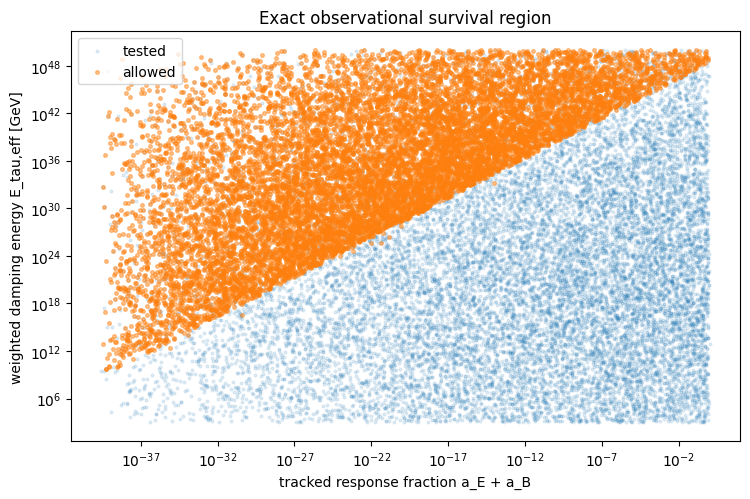

In [ ]:

# Downsample only for plotting.
plot_all = scan.sample(min(18000,len(scan)),random_state=46)
plot_allowed = allowed_scan.sample(min(12000,len(allowed_scan)),random_state=47)

plt.figure(figsize=(7.6,5.1))
plt.scatter(
    plot_all['a_sum'],
    plot_all['Etau_eff_GeV'],
    s=4,
    alpha=0.12,
    label='tested'
)
plt.scatter(
    plot_allowed['a_sum'],
    plot_allowed['Etau_eff_GeV'],
    s=7,
    alpha=0.45,
    label='allowed'
)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('tracked response fraction a_E + a_B')
plt.ylabel('weighted damping energy E_tau,eff [GeV]')
plt.title('Exact observational survival region')
plt.legend()
plt.tight_layout()
plt.savefig(outdir/'n46r_allowed_a_vs_damping_scale.png',dpi=180)
plt.show()


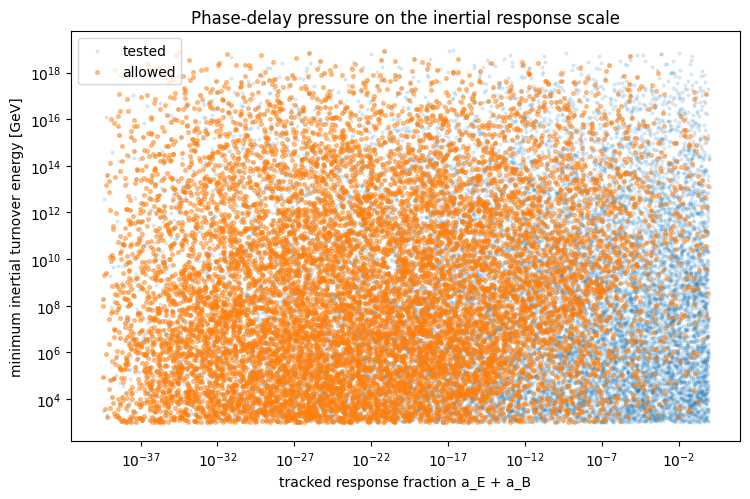

In [ ]:

plt.figure(figsize=(7.6,5.1))
plt.scatter(
    plot_all['a_sum'],
    plot_all['Eomega_min_GeV'],
    s=4,
    alpha=0.12,
    label='tested'
)
plt.scatter(
    plot_allowed['a_sum'],
    plot_allowed['Eomega_min_GeV'],
    s=7,
    alpha=0.45,
    label='allowed'
)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('tracked response fraction a_E + a_B')
plt.ylabel('minimum inertial turnover energy [GeV]')
plt.title('Phase-delay pressure on the inertial response scale')
plt.legend()
plt.tight_layout()
plt.savefig(outdir/'n46r_allowed_a_vs_inertial_scale.png',dpi=180)
plt.show()



## 8. Conditional analytic transparency frontier

In the coherent low-frequency branch,

\[
T_{\rm EM}
=
\hbar
\left(
\frac{a_E}{E_{\tau,E}}
+
\frac{a_B}{E_{\tau,B}}
\right).
\]

For a symmetric response,

\[
a_E=a_B=a,
\qquad
E_{\tau,E}=E_{\tau,B}=E_\tau,
\]

the \(7\) TeV transparency bound gives

\[
\boxed{
E_\tau
>
\frac{2a\hbar}{T_{\rm EM,max}}.
}
\]

This frontier shows why appreciable response fractions require extraordinarily weak bath damping.


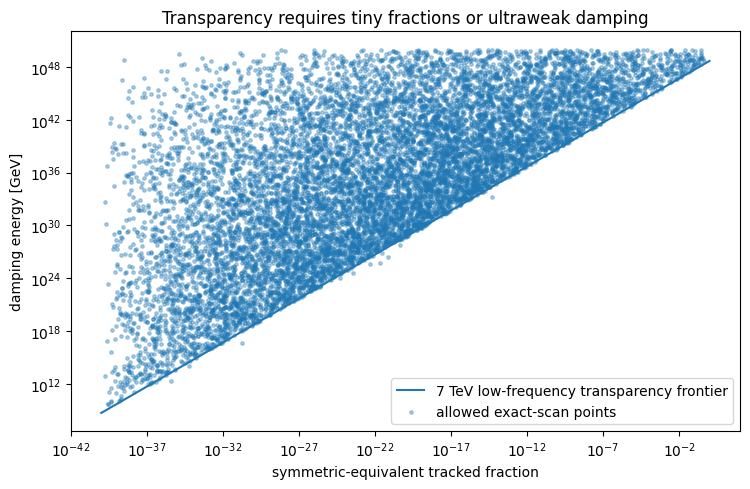

In [ ]:

Tmax_7TeV = float(
    opacity45.loc[
        np.isclose(opacity45['energy_TeV'],7.0),
        'T_EM_upper_s'
    ].iloc[0]
)

a_front = np.logspace(-40,0,500)
hbar_GeV_s = hbar/electron_volt/1e9
Etau_front = 2*a_front*hbar_GeV_s/Tmax_7TeV

frontier = pd.DataFrame({
    'symmetric_a':a_front,
    'minimum_Etau_GeV_low_frequency':Etau_front
})
frontier.to_csv(outdir/'n46r_symmetric_transparency_frontier.csv',index=False)

plt.figure(figsize=(7.6,5.0))
plt.loglog(a_front,Etau_front,label='7 TeV low-frequency transparency frontier')
plt.scatter(
    plot_allowed['a_sum']/2,
    plot_allowed['Etau_eff_GeV'],
    s=6,
    alpha=0.35,
    label='allowed exact-scan points'
)
plt.xlabel('symmetric-equivalent tracked fraction')
plt.ylabel('damping energy [GeV]')
plt.title('Transparency requires tiny fractions or ultraweak damping')
plt.legend()
plt.tight_layout()
plt.savefig(outdir/'n46r_transparency_frontier.png',dpi=180)
plt.show()



## 9. Representative benchmark points

The scan includes four interpretable regimes:

- appreciable response with ordinary sub-Planckian damping;
- tiny tracked fraction;
- appreciable response with ultraweak damping;
- turnover close to the observed TeV band.

These points demonstrate which mechanisms survive or fail.


In [ ]:

benchmarks = pd.DataFrame([
    {
        'name':'appreciable_subPlanckian',
        'aE':0.1,'aB':0.1,
        'EtauE_GeV':Epl_GeV,'EtauB_GeV':Epl_GeV,
        'EomegaE_GeV':Epl_GeV,'EomegaB_GeV':Epl_GeV
    },
    {
        'name':'tiny_fraction_subPlanckian',
        'aE':1e-30,'aB':1e-30,
        'EtauE_GeV':Epl_GeV,'EtauB_GeV':Epl_GeV,
        'EomegaE_GeV':Epl_GeV,'EomegaB_GeV':Epl_GeV
    },
    {
        'name':'appreciable_ultraweak_damping',
        'aE':0.1,'aB':0.1,
        'EtauE_GeV':1e49,'EtauB_GeV':1e49,
        'EomegaE_GeV':Epl_GeV,'EomegaB_GeV':Epl_GeV
    },
    {
        'name':'turnover_near_TeV',
        'aE':1e-18,'aB':1e-18,
        'EtauE_GeV':1e3,'EtauB_GeV':1e3,
        'EomegaE_GeV':3e3,'EomegaB_GeV':3e3
    }
])

bench_results = []
for _,r in benchmarks.iterrows():
    vals = {k:np.array([r[k]],dtype=float) for k in [
        'aE','aB','EtauE_GeV','EtauB_GeV','EomegaE_GeV','EomegaB_GeV'
    ]}
    vgL,nL = group_velocity_deviation(
        E_lo_GeV,vals['aE'],vals['aB'],
        vals['EtauE_GeV'],vals['EtauB_GeV'],
        vals['EomegaE_GeV'],vals['EomegaB_GeV']
    )
    vgH,nH = group_velocity_deviation(
        E_hi_GeV,vals['aE'],vals['aB'],
        vals['EtauE_GeV'],vals['EtauB_GeV'],
        vals['EomegaE_GeV'],vals['EomegaB_GeV']
    )
    vgG,nG = group_velocity_deviation(
        E_gw_GeV,vals['aE'],vals['aB'],
        vals['EtauE_GeV'],vals['EtauB_GeV'],
        vals['EomegaE_GeV'],vals['EomegaB_GeV']
    )
    tH = optical_depth(E_hi_GeV,nH)[0]
    pL = abs(vgH[0]-vgL[0]) <= lhaaso_delta_v_max
    pG = abs(vgG[0]) <= gw_speed_bound
    pT = tH <= 1
    bench_results.append({
        **r.to_dict(),
        'lhaaso_delta_v':abs(vgH[0]-vgL[0]),
        'gw_abs_speed_shift':abs(vgG[0]),
        'tau_extra_7TeV':tH,
        'pass_lhaaso':pL,
        'pass_gw':pG,
        'pass_transparency':pT,
        'allowed':pL and pG and pT
    })

benchmark_results = pd.DataFrame(bench_results)
benchmark_results.to_csv(outdir/'n46r_representative_benchmarks.csv',index=False)
benchmark_results


,name,aE,aB,EtauE_GeV,EtauB_GeV,EomegaE_GeV,EomegaB_GeV,lhaaso_delta_v,gw_abs_speed_shift,tau_extra_7TeV,pass_lhaaso,pass_gw,pass_transparency,allowed
0,appreciable_subPlanckian,1.000000e-01,1.000000e-01,1.220890e+19,1.220890e+19,1.220890e+19,1.220890e+19,8.211611e-33,1.677208e-48,4.075851e+28,True,True,False,False
1,tiny_fraction_subPlanckian,1.000000e-30,1.000000e-30,1.220890e+19,1.220890e+19,1.220890e+19,1.220890e+19,1.012051e-79,1.677208e-106,4.075851e-01,True,True,True,True
2,appreciable_ultraweak_damping,1.000000e-01,1.000000e-01,1.000000e+49,1.000000e+49,1.220890e+19,1.220890e+19,9.853933e-32,2.012650e-47,4.976166e-02,True,True,True,True
3,turnover_near_TeV,1.000000e-18,1.000000e-18,1.000000e+03,1.000000e+03,3.000000e+03,3.000000e+03,9.384157e-19,2.666667e-32,7.237734e+25,True,True,False,False



## 10. What the exact scan decides

The exact model has a nonempty survival region, but it is highly structured.

A point survives through one or both of the following mechanisms:

1. **Tiny tracked electromagnetic fractions**
   \[
   a_E,\ a_B\ll1;
   \]
2. **Extremely weak bath damping**
   \[
   E_{\tau,E},E_{\tau,B}\gg E_{\rm Pl},
   \]
   which means \(\Gamma_j/M_j^2\) is exceptionally small.

The phase-delay constraints additionally push appreciable response toward high inertial turnover
scales \(E_{\Omega,j}\).

Turnovers inside the observed band can survive only when their tracked amplitudes are so small
that the resulting phase and absorption signatures remain negligible.


In [ ]:

# Quantify practical branches.
appreciable = allowed_scan[allowed_scan['a_sum']>=1e-3]
tiny = allowed_scan[allowed_scan['a_sum']<1e-20]
turnover = allowed_scan[~allowed_scan['low_frequency_valid_at_7TeV']]

branch_quantiles = []
for name,df in [
    ('appreciable_a_sum_ge_1e-3',appreciable),
    ('tiny_a_sum_lt_1e-20',tiny),
    ('turnover_near_or_below_band',turnover)
]:
    branch_quantiles.append({
        'branch':name,
        'count':len(df),
        'median_a_sum':np.nan if len(df)==0 else df['a_sum'].median(),
        'median_Etau_eff_GeV':np.nan if len(df)==0 else df['Etau_eff_GeV'].median(),
        'minimum_Etau_eff_GeV':np.nan if len(df)==0 else df['Etau_eff_GeV'].min(),
        'median_Eomega_min_GeV':np.nan if len(df)==0 else df['Eomega_min_GeV'].median()
    })

branch_quantiles = pd.DataFrame(branch_quantiles)
branch_quantiles.to_csv(outdir/'n46r_branch_quantiles.csv',index=False)
branch_quantiles


,branch,count,median_a_sum,median_Etau_eff_GeV,minimum_Etau_eff_GeV,median_Eomega_min_GeV
0,appreciable_a_sum_ge_1e-3,214,1.898536e-02,1.927300e+48,3.503953e+45,6.430189e+10
1,tiny_a_sum_lt_1e-20,11301,4.510303e-28,3.826504e+30,2.978637e+09,4.971436e+07
2,turnover_near_or_below_band,3575,1.209046e-24,3.594884e+34,1.013564e+10,7.787098e+03



## 11. Falsifiability result

The N44R closure is not automatically excluded, but the observations strongly restrict its
physical interpretation.

If ECSM intends \(a_E\) and \(a_B\) to be order-one fractions of the observed vacuum constants,
then the damping ratios

\[
\tau_E=\frac{\Gamma_E}{M_E^2},
\qquad
\tau_B=\frac{\Gamma_B}{M_B^2}
\]

must be extraordinarily small, and the inertial turnover must remain above the observed
propagation band.

If the bath coupling is not ultraweak, the tracked fractions must instead be tiny.

Therefore the electromagnetic sector cannot simultaneously have:

- appreciable tracked fractions;
- ordinary finite damping;
- and a turnover near currently observed photon energies.

That combination is observationally rejected by the exact response scan.



## 12. N46R verdict

### Passed

- exact N44 response evaluated without the quadratic approximation;
- nonempty allowed region found;
- LHAASO, GW170817, and exact transparency envelopes applied;
- stable positive constitutive branches enforced;
- allowed points separated into coherent and turnover regimes;
- analytic transparency frontier recovered;
- representative success and failure points exported.

### Final electromagnetic scan result

\[
\boxed{
\text{The N44 closure survives, but only in a narrow physical hierarchy.}
}
\]

The viable hierarchy is:

\[
\boxed{
\text{high inertial turnover}
+
\left(
\text{tiny tracked fraction}
\ \text{or}\
\text{ultraweak damping}
\right).
}
\]

### Next step

The major exploratory chain should now stop.

The correct next deliverable is the synthesis paper that combines:

- corrected gauge-sector propagation;
- the SI nonlinear dictionary;
- causal split response;
- microscopic polarisation/magnetisation closure;
- exact observational survival limits;
- and explicit failure conditions.


In [ ]:

tests = pd.DataFrame([
    ['N45 ledger imported',EQG2_GeV>0,EQG2_GeV],
    ['Maxwell evaluator',np.isclose(test[0][0],0.0),test[0][0]],
    ['positive LHAASO envelope',lhaaso_delta_v_max>0,lhaaso_delta_v_max],
    ['deterministic scan size',N==100000,N],
    ['nonempty exact survival region',n_allowed>0,n_allowed],
    ['allowed table consistency',len(allowed_scan)==n_allowed,len(allowed_scan)],
    ['positive path length',path_m>0,path_m],
    ['positive transparency frontier',np.all(Etau_front>0),True],
    ['representative benchmarks complete',len(benchmark_results)==4,len(benchmark_results)],
    ['branch summary complete',len(branch_summary)==5,len(branch_summary)],
    ['scan output finite',np.all(np.isfinite(scan[['a_sum','Etau_eff_GeV','Eomega_min_GeV']])),True],
    ['survivors satisfy all constraints',
     bool(np.all(
         allowed_scan['pass_lhaaso']&
         allowed_scan['pass_gw']&
         allowed_scan['pass_transparency']
     )),
     True],
],columns=['test','pass','value'])

tests.to_csv(outdir/'n46r_summary_tests.csv',index=False)
assert tests['pass'].all()
tests


,test,pass,value
0,N45 ledger imported,True,732533999999.999878
1,Maxwell evaluator,True,-0.0
2,positive LHAASO envelope,True,0.0
3,deterministic scan size,True,100000
4,nonempty exact survival region,True,19417
5,allowed table consistency,True,19417
6,positive path length,True,20039423189113938047401984.0
7,positive transparency frontier,True,True
8,representative benchmarks complete,True,4
9,branch summary complete,True,5


In [ ]:

ledger = {
    'notebook':'ECSM_N46R_Exact_Electromagnetic_Response_Survival_Scan',
    'status':'final major electromagnetic survival scan complete',
    'tests_passed':int(tests['pass'].sum()),
    'tests_total':int(len(tests)),
    'scan_size':int(N),
    'allowed_count':int(n_allowed),
    'allowed_fraction':float(n_allowed/N),
    'constraints':{
        'LHAASO_pairwise_delta_v_max':float(lhaaso_delta_v_max),
        'GW170817_abs_speed_bound':float(gw_speed_bound),
        'extra_optical_depth_cap':1.0,
        'path_Mpc':float(path_Mpc)
    },
    'survival_hierarchy':'high inertial turnover plus tiny tracked fraction or ultraweak damping',
    'main_rejection':'appreciable tracked fraction with ordinary finite damping and near-band turnover',
    'claim_boundary':'broad deterministic survival scan, not posterior inference',
    'next_stage':'write the electromagnetic closure and observational survival synthesis paper'
}

with open(outdir/'n46r_claim_ledger.json','w') as f:
    json.dump(ledger,f,indent=2)

readme = f'''# ECSM N46R outputs

Final major exact-response electromagnetic survival scan.

Scan size: {N}
Allowed points: {n_allowed}
Allowed fraction: {n_allowed/N:.6g}

Exact constraints:
- LHAASO 0.2--7 TeV differential group speed
- GW170817 representative 100 keV speed consistency
- exact extra transparency at 0.2, 1, and 7 TeV
- finite, positive, passive constitutive response

Main result:
The N44 closure has a nonempty survival region, but viable points require high inertial turnover
plus either tiny tracked response fractions or ultraweak damping.

This is a survival scan, not a posterior fit.
'''
(outdir/'README.md').write_text(readme)

manifest = pd.DataFrame([
    {'file':p.name,'bytes':p.stat().st_size}
    for p in sorted(outdir.iterdir())
])
manifest.to_csv(outdir/'n46r_manifest.csv',index=False)

print(json.dumps(ledger,indent=2))


{
  "notebook": "ECSM_N46R_Exact_Electromagnetic_Response_Survival_Scan",
  "status": "final major electromagnetic survival scan complete",
  "tests_passed": 12,
  "tests_total": 12,
  "scan_size": 100000,
  "allowed_count": 19417,
  "allowed_fraction": 0.19417,
  "constraints": {
    "LHAASO_pairwise_delta_v_max": 1.3686017605129108e-16,
    "GW170817_abs_speed_bound": 3e-15,
    "extra_optical_depth_cap": 1.0,
    "path_Mpc": 649.433476436916
  },
  "survival_hierarchy": "high inertial turnover plus tiny tracked fraction or ultraweak damping",
  "main_rejection": "appreciable tracked fraction with ordinary finite damping and near-band turnover",
  "claim_boundary": "broad deterministic survival scan, not posterior inference",
  "next_stage": "write the electromagnetic closure and observational survival synthesis paper"
}
